# Determining head movement using continous HPI 
Thanks to [Line Kruse](https://github.com/LineKruse) for providing the code that formed the basis of this notebook. 

In [10]:
import mne
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# importing from your local utils
import sys
sys.path.append("../scripts")
from params import fnames, DATES

In [11]:
subject = "0195"
date = DATES.get(subject)

raw_sub_path = fnames.sub_raw(subject=subject, date=date)
raw = mne.io.read_raw_fif(raw_sub_path)

# CROPPING THE DATA FOR SPEED HERE!
raw.crop(200, 400)

Opening raw data file /work/raw/0195/20260910_000000/workshop_2026_raw.fif...
    Read a total of 9 projection items:
        planar-Raw-0.000-120.000-PCA-01 (1 x 203)  idle
        planar-Raw-0.000-120.000-PCA-02 (1 x 203)  idle
        planar-Raw-0.000-120.000-PCA-03 (1 x 203)  idle
        axial-Raw-0.000-120.000-PCA-01 (1 x 102)  idle
        axial-Raw-0.000-120.000-PCA-02 (1 x 102)  idle
        axial-Raw-0.000-120.000-PCA-03 (1 x 102)  idle
        axial-Raw-0.000-120.000-PCA-04 (1 x 102)  idle
        axial-Raw-0.000-120.000-PCA-05 (1 x 102)  idle
        axial-Raw-0.000-120.000-PCA-06 (1 x 102)  idle
    Range : 200000 ... 1796999 =    200.000 ...  1796.999 secs
Ready.
Opening raw data file /work/raw/0195/20260910_000000/workshop_2026_raw-1.fif...
    Read a total of 9 projection items:
        planar-Raw-0.000-120.000-PCA-01 (1 x 203)  idle
        planar-Raw-0.000-120.000-PCA-02 (1 x 203)  idle
        planar-Raw-0.000-120.000-PCA-03 (1 x 203)  idle
        axial-Raw-0.000-12

<Raw | workshop_2026_raw.fif, 313 x 200001 (200.0 s), ~5.2 MiB, data not loaded>

In [12]:
chpi_freqs, ch_idx, chpi_codes = mne.chpi.get_chpi_info(info=raw.info)

Using 4 HPI coils: 220 245 270 295 Hz


Question: Does this match with anything in the PSD?

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


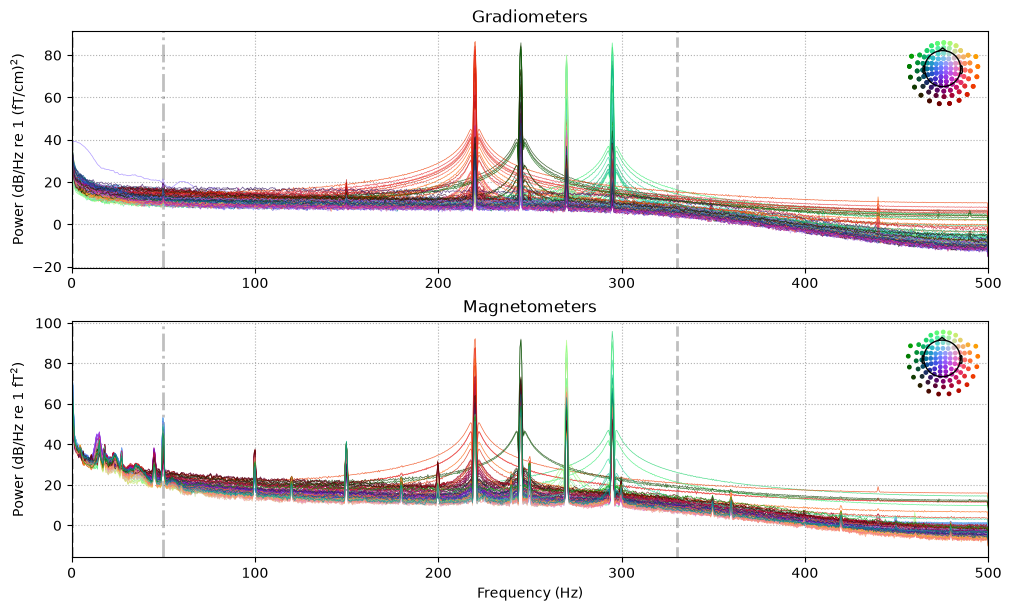

In [13]:
raw.compute_psd().plot();

In [14]:
#Extract HPI coil amplitudes as a function of time and save 
chpi_amplitudes = mne.chpi.compute_chpi_amplitudes(raw, verbose=0)
print(chpi_amplitudes)

  0%|          | cHPI amplitudes : 0/19991 [00:00<?,       ?it/s]

--- chpi amplitudes -----
{'proj': <Projection | SSS, active : False, n_channels : 306>, 'times': array([400.  , 400.01, 400.02, ..., 599.88, 599.89, 599.9 ],
      shape=(19991,)), 'slopes': array([[[ 2.42724711e-12, -7.36101114e-12,  1.68697371e-12, ...,
          3.03148068e-11,  1.87113531e-09, -1.38534967e-09],
        [ 2.71375053e-12, -5.08311395e-11, -3.34742181e-11, ...,
         -6.33656332e-13,  8.64863497e-12, -5.65279110e-12],
        [-1.22958388e-12,  4.41567116e-12,  1.63409928e-11, ...,
         -4.17784478e-14,  1.54433354e-11,  1.81226719e-11],
        [ 4.68759770e-12, -1.21281093e-11, -3.04242861e-11, ...,
         -2.17528030e-12, -1.91146600e-12,  6.18771342e-12]],

       [[-2.42462778e-12,  7.67069047e-12, -1.46597857e-12, ...,
         -3.03198349e-11, -1.87104877e-09,  1.38521385e-09],
        [-2.71365443e-12,  5.12755173e-11,  3.36798247e-11, ...,
          6.29527367e-13, -8.25699344e-12,  5.64322714e-12],
        [ 1.22548950e-12, -4.07553616e-12, -1.6006

In [15]:
#Compute time-varying HPI coil locations from those 
chpi_locs = mne.chpi.compute_chpi_locs(raw.info, chpi_amplitudes, verbose=0)
print(chpi_locs)

  0%|          | cHPI locations  : 0/19991 [00:00<?,       ?it/s]

{'times': array([400., 401., 402., 403., 404., 405., 406., 407., 408., 409., 410.,
       411., 412., 413., 414., 415., 416., 417., 418., 419., 420., 421.,
       422., 423., 424., 425., 426., 427., 428., 429., 430., 431., 432.,
       433., 434., 435., 436., 437., 438., 439., 440., 441., 442., 443.,
       444., 445., 446., 447., 448., 449., 450., 451., 452., 453., 454.,
       455., 456., 457., 458., 459., 460., 461., 462., 463., 464., 465.,
       466., 467., 468., 469., 470., 471., 472., 473., 474., 475., 476.,
       477., 478., 479., 480., 481., 482., 483., 484., 485., 486., 487.,
       488., 489., 490., 491., 492., 493., 494., 495., 496., 497., 498.,
       499., 500., 501., 502., 503., 504., 505., 506., 507., 508., 509.,
       510., 511., 512., 513., 514., 515., 516., 517., 518., 519., 520.,
       521., 522., 523., 524., 525., 526., 527., 528., 529., 530., 531.,
       532., 533., 534., 535., 536., 537., 538., 539., 540., 541., 542.,
       543., 544., 545., 546., 547., 548.

In [16]:
head_pos = mne.chpi.compute_head_pos(raw.info, chpi_locs, verbose=0)

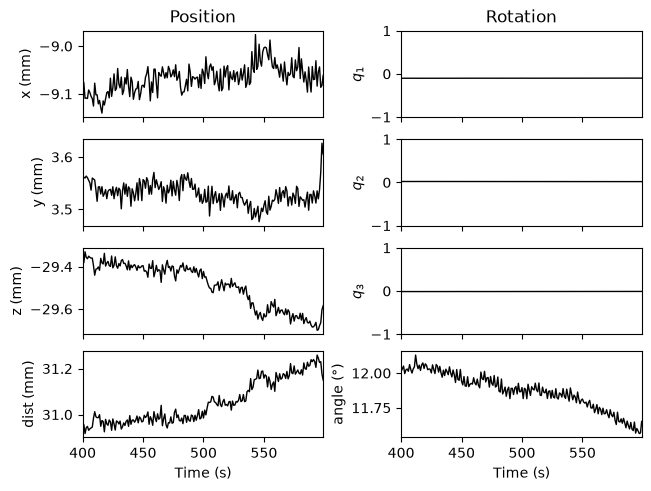

In [17]:
#Plot continuous head position
mne.viz.plot_head_positions(head_pos, mode='traces', totals=True);


Note: If you have a report, you can add figures to them using the report.add_figure() method. See documentation [here](https://mne.tools/stable/generated/mne.Report.html#mne.Report.add_figure).